In [1]:
pip install numpy matplotlib tensorflow

In [2]:
import pickle
import numpy as np

# Load dataset
with open("RML2016.10a_dict.pkl", 'rb') as f:
    Xd = pickle.load(f, encoding='latin1')

print(type(Xd))

<class 'dict'>


In [3]:
snrs, mods = map(lambda j: sorted(list(set(map(lambda x: x[j], Xd.keys())))), [1,0])

print("Modulations:", mods)
print("SNR levels:", snrs)

Modulations: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR levels: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [4]:
X = []
Y = []

for mod in mods:
    for snr in snrs:
        X.append(Xd[(mod, snr)])
        for i in range(Xd[(mod, snr)].shape[0]):
            Y.append(mod)

X = np.vstack(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (220000, 2, 128)
Y shape: (220000,)


In [5]:
print(X[0])

[[-7.1637910e-03 -2.4163153e-03  6.3236820e-04  7.6600756e-03
  -5.5389893e-03 -2.5629399e-03 -7.0367334e-03 -4.9818424e-03
   1.5957376e-02  6.1459891e-03  1.3795516e-03  1.2737102e-02
   8.8173831e-03 -3.8743219e-03 -1.9763107e-03 -6.3405237e-03
  -9.9432003e-03  1.6306845e-03 -2.6596576e-04 -8.7097697e-03
  -2.6659328e-03  4.4714739e-03  7.2397892e-03  6.1522629e-03
   7.7812858e-03 -4.9577984e-03 -3.4882885e-03 -9.7634532e-03
  -4.9338224e-03 -2.9843643e-03  7.3233922e-04 -9.0569276e-03
  -3.6061467e-03 -2.8891859e-03  4.3964055e-03  5.2717999e-03
  -5.2130306e-03  7.3736985e-03  2.6283292e-03 -5.4228045e-03
  -4.3541370e-03 -1.6163584e-03  9.8071350e-03  4.9552917e-03
  -1.1189183e-03  9.2804842e-03 -1.0600986e-02 -1.8081943e-03
   9.3074059e-03 -7.3733628e-03  5.2728658e-03 -5.4935738e-03
   7.2285812e-03 -3.2198154e-03 -9.9363329e-04  1.3661309e-03
  -5.0005326e-03  7.7800560e-03  8.8354358e-03  7.0654382e-03
   1.1981672e-02  2.7984669e-03 -3.8660385e-04 -8.8727884e-03
   2.142

In [6]:
X = np.transpose(X, (0, 2, 1))
print(X.shape)

(220000, 128, 2)


In [7]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Convert labels to numbers
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)

# Convert to one-hot
Y_onehot = to_categorical(Y_encoded)

print(Y_onehot.shape)

(220000, 11)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_onehot, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(176000, 128, 2) (44000, 128, 2)


In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Conv Layer 1
    layers.Conv1D(64, kernel_size=3, activation='relu', input_shape=(128, 2)),
    layers.MaxPooling1D(pool_size=2),

    # Conv Layer 2
    layers.Conv1D(128, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),

    # Flatten
    layers.Flatten(),

    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dense(11, activation='softmax')  # 11 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 518,219 (1.98 MB)

 Trainable params: 518,219 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, Y_test)
)

Epoch 1/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 118s 81ms/step - accuracy: 0.2622 - loss: 1.9673 - val_accuracy: 0.3414 - val_loss: 1.7512
Epoch 2/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 108s 79ms/step - accuracy: 0.3602 - loss: 1.7099 - val_accuracy: 0.3923 - val_loss: 1.6399
Epoch 3/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 140s 77ms/step - accuracy: 0.4090 - loss: 1.5871 - val_accuracy: 0.4216 - val_loss: 1.5396
Epoch 4/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 104s 75ms/step - accuracy: 0.4392 - loss: 1.4959 - val_accuracy: 0.4469 - val_loss: 1.4555
Epoch 5/5
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 105s 76ms/step - accuracy: 0.4621 - loss: 1.4274 - val_accuracy: 0.4744 - val_loss: 1.4039


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # CNN layers
    layers.Conv1D(64, 3, activation='relu', input_shape=(128, 2)),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 3, activation='relu'),
    layers.MaxPooling1D(2),

    # LSTM layer (IMPORTANT)
    layers.LSTM(64),

    # Dense
    layers.Dense(128, activation='relu'),
    layers.Dense(11, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,299 (329.29 KB)

 Trainable params: 84,299 (329.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=3,
    batch_size=128,
    validation_data=(X_test, Y_test)
)

Epoch 1/3
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 198s 141ms/step - accuracy: 0.2568 - loss: 1.9582 - val_accuracy: 0.3528 - val_loss: 1.7178
Epoch 2/3
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 181s 132ms/step - accuracy: 0.3898 - loss: 1.6152 - val_accuracy: 0.4211 - val_loss: 1.5185
Epoch 3/3
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 178s 129ms/step - accuracy: 0.4431 - loss: 1.4585 - val_accuracy: 0.4465 - val_loss: 1.4495


In [12]:
import numpy as np
import pickle

# Load the raw dictionary (RadioML 2016.10a)
with open('RML2016.10a_dict.pkl', 'rb') as f:
    Xd = pickle.load(f, encoding='latin1')

snrs, mods = map(lambda j: sorted(list(set(map(lambda x: x[j], Xd.keys())))), [1, 0])

X = []
lbl = []

for mod in mods:
    for snr in snrs:
        X.append(Xd[(mod, snr)])
        for i in range(Xd[(mod, snr)].shape[0]):
            # Store the modulation and the SNR for every single 128x2 sample
            lbl.append((mod, snr))

X = np.vstack(X) # Shape becomes (220000, 2, 128)

In [13]:
# Change from (2, 128) to (128, 2)
X = np.transpose(X, (0, 2, 1))
print(f"Final Data Shape: {X.shape}") # Should be (220000, 128, 2)

Final Data Shape: (220000, 128, 2)


In [14]:
from tensorflow.keras import layers, models, optimizers

model = models.Sequential([
    # Input Layer
    layers.Input(shape=(128, 2)),

    # CNN Block 1 - Added BatchNormalization
    layers.Conv1D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    # CNN Block 2
    layers.Conv1D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    # LSTM for temporal memory
    layers.LSTM(64),

    # Output
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(11, activation='softmax')
])

# Use a specific learning rate (0.001 is standard)
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# 1. Separate the labels and the SNR values from our 'lbl' list
Y_str = [item[0] for item in lbl]
snr_all = np.array([item[1] for item in lbl])

# 2. Encode labels as numbers (as we did before)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_numeric = le.fit_transform(Y_str)

# 3. Split the data (Including the snr_all array!)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test, snr_train, snr_test = train_test_split(
    X, Y_numeric, snr_all, test_size=0.2, random_state=42
)

# --- ASSUME MODEL TRAINING HAPPENS HERE ---

# 4. Calculate Accuracy per SNR level
acc_per_snr = {}
Y_pred = np.argmax(model.predict(X_test), axis=1)

for snr in np.unique(snr_test):
    # Find indices where the SNR matches the current level
    indices = np.where(snr_test == snr)

    # Calculate accuracy for just those indices
    accuracy = np.mean(Y_pred[indices] == Y_test[indices])
    acc_per_snr[snr] = accuracy
    print(f"SNR {snr}dB: Accuracy = {accuracy:.4f}")

1375/1375 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step
SNR -20dB: Accuracy = 0.0987
SNR -18dB: Accuracy = 0.0979
SNR -16dB: Accuracy = 0.0964
SNR -14dB: Accuracy = 0.1133
SNR -12dB: Accuracy = 0.1125
SNR -10dB: Accuracy = 0.1042
SNR -8dB: Accuracy = 0.1085
SNR -6dB: Accuracy = 0.1123
SNR -4dB: Accuracy = 0.1055
SNR -2dB: Accuracy = 0.1150
SNR 0dB: Accuracy = 0.1143
SNR 2dB: Accuracy = 0.1147
SNR 4dB: Accuracy = 0.1211
SNR 6dB: Accuracy = 0.1323
SNR 8dB: Accuracy = 0.1187
SNR 10dB: Accuracy = 0.1291
SNR 12dB: Accuracy = 0.1378
SNR 14dB: Accuracy = 0.1299
SNR 16dB: Accuracy = 0.1200
SNR 18dB: Accuracy = 0.1279


In [38]:
import numpy as np

# 1. Normalization: Scale everything between -1 and 1
X_normalized = X / np.max(np.abs(X))

# 2. Re-split with the normalized data
X_train, X_test, Y_train, Y_test, snr_train, snr_test = train_test_split(
    X_normalized, Y_onehot, snr_all, test_size=0.2, random_state=42
)

# 3. Build the Updated Model
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv1D(64, 3, activation='relu', input_shape=(128, 2)),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 3, activation='relu'),
    layers.MaxPooling1D(2),
    layers.LSTM(64), # The "Memory" component
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # The "Generalizer"
    layers.Dense(11, activation='softmax')
])
layers.BatchNormalization()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
layers.Conv1D(64, 3, activation='relu'),
layers.BatchNormalization(),
layers.MaxPooling1D(2),

(<MaxPooling1D name=max_pooling1d_9, built=True>,)

In [24]:
layers.Dropout(0.3)

<Dropout name=dropout_3, built=True>

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop]
)

Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 182s 130ms/step - accuracy: 0.2969 - loss: 1.8597 - val_accuracy: 0.4182 - val_loss: 1.5069
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.4533 - loss: 1.4207 - val_accuracy: 0.4745 - val_loss: 1.3509
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 173s 126ms/step - accuracy: 0.4910 - loss: 1.3184 - val_accuracy: 0.5077 - val_loss: 1.2667
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 175s 127ms/step - accuracy: 0.5069 - loss: 1.2796 - val_accuracy: 0.5095 - val_loss: 1.2538
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 172s 125ms/step - accuracy: 0.5170 - loss: 1.2548 - val_accuracy: 0.5218 - val_loss: 1.2508
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 211s 132ms/step - accuracy: 0.5234 - loss: 1.2385 - val_accuracy: 0.5276 - val_loss: 1.2190
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 171s 125ms/step - accuracy: 0.5319 - loss: 1.2205 - val_accuracy: 0.5303 - val_loss: 1.1972
Epoch 8/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 201s 124ms/step - ac

In [26]:
idx = snr_all >= 0   # keep 0 dB and above

X = X[idx]
Y_onehot = Y_onehot[idx]
snr_all = snr_all[idx]

In [27]:
layers.Conv1D(256, 3, activation='relu'),
layers.BatchNormalization(),
layers.MaxPooling1D(2),

(<MaxPooling1D name=max_pooling1d_10, built=True>,)

In [28]:
history = model.fit(
    X_train, Y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_test, Y_test)
)

Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 169s 120ms/step - accuracy: 0.2884 - loss: 1.8720 - val_accuracy: 0.3756 - val_loss: 1.6046
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 164s 119ms/step - accuracy: 0.4104 - loss: 1.5109 - val_accuracy: 0.4575 - val_loss: 1.4048
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 202s 119ms/step - accuracy: 0.4714 - loss: 1.3612 - val_accuracy: 0.4907 - val_loss: 1.2800
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 163s 119ms/step - accuracy: 0.4964 - loss: 1.2928 - val_accuracy: 0.5166 - val_loss: 1.2426
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 201s 118ms/step - accuracy: 0.5100 - loss: 1.2610 - val_accuracy: 0.5191 - val_loss: 1.2322
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 163s 118ms/step - accuracy: 0.5227 - loss: 1.2375 - val_accuracy: 0.5159 - val_loss: 1.2319
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 204s 120ms/step - accuracy: 0.5327 - loss: 1.2173 - val_accuracy: 0.5433 - val_loss: 1.1894
Epoch 8/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 164s 119ms/step - ac

In [29]:
X_fft = np.fft.fft(X, axis=1)

# Take magnitude
X_fft = np.abs(X_fft)

In [30]:
X_fft = X_fft / np.max(X_fft)

In [32]:
import numpy as np

# 1. Apply Fast Fourier Transform along the time axis (128 samples)
# X shape is (220000, 128, 2) -> We treat I and Q as a complex signal
X_complex = X[:,:,0] + 1j*X[:,:,1]
X_fft = np.fft.fft(X_complex, axis=1)

# 2. Get Magnitude and Phase (This gives the AI 2 new 'channels' to look at)
X_mag = np.abs(X_fft)
X_phase = np.angle(X_fft)

# 3. Stack them back into (samples, 128, 2)
X_final = np.stack((X_mag, X_phase), axis=-1)

# 4. CRITICAL: Normalize the FFT data
X_final = X_final / np.max(X_final)

# 5. Re-split
X_train, X_test, Y_train, Y_test, snr_train, snr_test = train_test_split(
    X_final, Y_onehot, snr_all, test_size=0.2, random_state=42
)

In [33]:
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.3442 - loss: 1.7011 - val_accuracy: 0.4796 - val_loss: 1.2868
Epoch 2/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 141s 122ms/step - accuracy: 0.4722 - loss: 1.2874 - val_accuracy: 0.4970 - val_loss: 1.2079
Epoch 3/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 90s 131ms/step - accuracy: 0.4972 - loss: 1.2154 - val_accuracy: 0.5098 - val_loss: 1.1637
Epoch 4/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 86s 125ms/step - accuracy: 0.5095 - loss: 1.1704 - val_accuracy: 0.5209 - val_loss: 1.1289
Epoch 5/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 85s 123ms/step - accuracy: 0.5167 - loss: 1.1401 - val_accuracy: 0.5285 - val_loss: 1.1042
Epoch 6/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 145s 128ms/step - accuracy: 0.5230 - loss: 1.1184 - val_accuracy: 0.5335 - val_loss: 1.0787
Epoch 7/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.5269 - loss: 1.0975 - val_accuracy: 0.5343 - val_loss: 1.0630
Epoch 8/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 83s 121ms/step - accuracy: 0.5323 - loss

In [40]:
# FFT
X_fft = np.fft.fft(X, axis=1)
X_fft = np.abs(X_fft)

# Normalize both
X = X / np.max(np.abs(X))
X_fft = X_fft / np.max(X_fft)

# Combine
X_combined = np.concatenate((X, X_fft), axis=2)

print(X_combined.shape)

# Re-split data with X_combined
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test, snr_train, snr_test = train_test_split(
    X_combined, Y_onehot, snr_all, test_size=0.2, random_state=42
)


(110000, 128, 4)


In [35]:
layers.Bidirectional(layers.LSTM(64))

<Bidirectional name=bidirectional, built=False>

In [39]:
model = models.Sequential([

    layers.Conv1D(64, 3, activation='relu', input_shape=(128, 4)),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Conv1D(128, 3, activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),

    layers.Bidirectional(layers.LSTM(64)),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(11, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    X_train, Y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_test, Y_test)
)

Epoch 1/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 148s 206ms/step - accuracy: 0.7051 - loss: 0.6065 - val_accuracy: 0.6464 - val_loss: 1.1010
Epoch 2/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 141s 205ms/step - accuracy: 0.7998 - loss: 0.3807 - val_accuracy: 0.8173 - val_loss: 0.3656
Epoch 3/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 142s 207ms/step - accuracy: 0.8366 - loss: 0.3132 - val_accuracy: 0.7720 - val_loss: 0.5261
Epoch 4/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 144s 209ms/step - accuracy: 0.8602 - loss: 0.2797 - val_accuracy: 0.8542 - val_loss: 0.2914
Epoch 5/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 141s 206ms/step - accuracy: 0.8772 - loss: 0.2575 - val_accuracy: 0.8370 - val_loss: 0.3676
Epoch 6/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 142s 206ms/step - accuracy: 0.8856 - loss: 0.2435 - val_accuracy: 0.8670 - val_loss: 0.2651
Epoch 7/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 143s 207ms/step - accuracy: 0.8908 - loss: 0.2308 - val_accuracy: 0.8785 - val_loss: 0.2676
Epoch 8/10
688/688 ━━━━━━━━━━━━━━━━━━━━ 141s 205ms/step - accuracy: 0.8966 -

688/688 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step
SNR 0dB: Accuracy = 0.8082
SNR 2dB: Accuracy = 0.8405
SNR 4dB: Accuracy = 0.8583
SNR 6dB: Accuracy = 0.8974
SNR 8dB: Accuracy = 0.8781
SNR 10dB: Accuracy = 0.8781
SNR 12dB: Accuracy = 0.8880
SNR 14dB: Accuracy = 0.8867
SNR 16dB: Accuracy = 0.8687
SNR 18dB: Accuracy = 0.8855


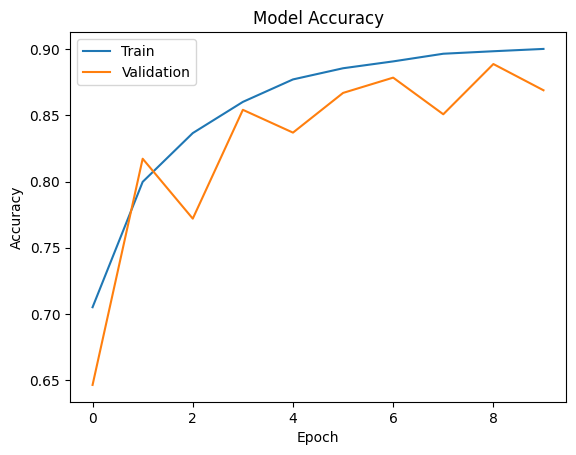

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Re-calculate Accuracy per SNR level for the latest model and data
acc_per_snr = {}
Y_pred = np.argmax(model.predict(X_test), axis=1)

# Convert Y_test from one-hot to numerical labels for comparison
Y_test_numerical = np.argmax(Y_test, axis=1)

for snr_level in np.unique(snr_test):
    # Find indices where the SNR matches the current level
    indices = np.where(snr_test == snr_level)

    # Calculate accuracy for just those indices
    accuracy = np.mean(Y_pred[indices] == Y_test_numerical[indices])
    acc_per_snr[snr_level] = accuracy
    print(f"SNR {snr_level}dB: Accuracy = {accuracy:.4f}")

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

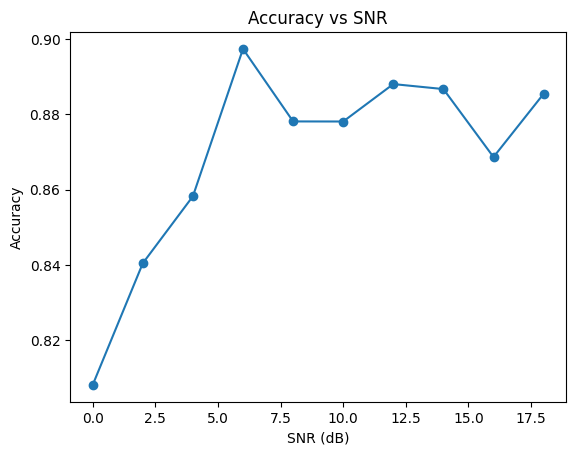

In [46]:
plt.plot(list(acc_per_snr.keys()), list(acc_per_snr.values()), marker='o')
plt.title("Accuracy vs SNR")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.show()

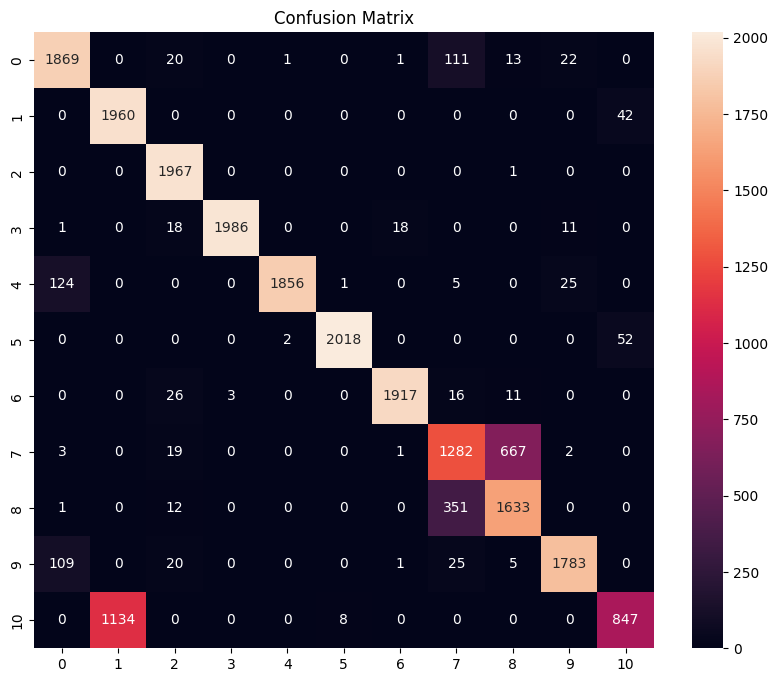

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test_numerical, Y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()